# Differential Equations for Machine Learning
## Notebook 02 — Systems of ODEs and the Lorenz System

### Objective

In Notebook 01, we studied a single ODE:

    dy/dt = 2y

Now we move to systems of differential equations.

We will learn:

1. What a system of ODEs is
2. How multiple variables can depend on each other
3. How to represent an ODE system in Python
4. Numerical integration with `solve_ivp`
5. The Lorenz system
6. Phase space
7. Chaotic behavior
8. Sensitivity to initial conditions

The Lorenz system will eventually become our first serious PINN problem.

# 1. From One Variable to Multiple Variables

Previously we had:

    dy/dt = 2y

There was only one unknown variable:

    y(t)

Now imagine that we have three variables:

    x(t)
    y(t)
    z(t)

and each variable changes according to the others.

For example:

    dx/dt = y
    dy/dt = -x

This is called a system of ordinary differential equations.

We can think of the complete state as a vector:

    u(t) = [x(t), y(t)]

or:

    u(t) = [x(t), y(t), z(t)]

The differential equation then becomes:

    du/dt = f(t, u)

This form is extremely important because this is exactly the form expected
by numerical ODE solvers such as `solve_ivp`.

# 2. A Simple Two-Variable System

Consider:

    dx/dt = y

    dy/dt = -x

Notice something interesting.

The change in `x` depends on `y`.

The change in `y` depends on `x`.

Therefore the two variables are coupled.

This system produces oscillatory motion.

We can think of:

    x → affects y
    y → affects x

This kind of coupled system appears throughout physics and engineering.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [ ]:
def oscillator(t, state):
    """
    Two-variable system:

        dx/dt = y
        dy/dt = -x

    Parameters
    ----------
    t : float
        Current time.

    state : array-like
        Current state [x, y].

    Returns
    -------
    list
        [dx/dt, dy/dt]
    """

    x, y = state
    
    dx_dt = y
    dy_dt = -x

    return [dx_dt, dy_dt]

# 3. Initial Conditions for a System

For a single ODE we needed:

    y(0) = y₀

For a system, we need the initial value of every variable.

For example:

    x(0) = 1
    y(0) = 0

So our initial state is:

    [1, 0]

This completely specifies where the simulation starts.

In [4]:
initial_state = [1, 0]

solution = solve_ivp(
    oscillator,
    (0, 20),
    initial_state,
    t_eval=np.linspace(0, 20, 1000)
)

print("Number of time points:", len(solution.t))
print("First state:", solution.y[:, 0])
print("Last state:", solution.y[:, -1])

Number of time points: 1000
First state: [1. 0.]
Last state: [ 0.40273088 -0.91506103]


# 4. Understanding `solution.y`

For a system containing two variables:

    x(t)
    y(t)

`solution.y` has two rows.

Conceptually:

              t₀    t₁    t₂    t₃    ...
    x(t)      x₀    x₁    x₂    x₃    ...
    y(t)      y₀    y₁    y₂    y₃    ...

Therefore:

    solution.y[0]

contains all x values.

And:

    solution.y[1]

contains all y values.

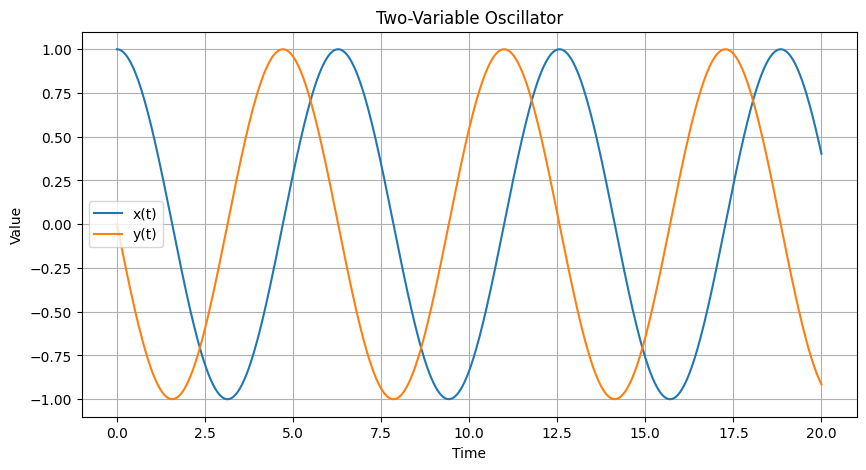

In [5]:
t = solution.t

x = solution.y[0]
y = solution.y[1]

plt.figure(figsize=(10, 5))

plt.plot(t, x, label="x(t)")
plt.plot(t, y, label="y(t)")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Two-Variable Oscillator")
plt.grid(True)
plt.legend()

plt.show()

# 5. Phase Space

Instead of plotting variables against time, we can plot one variable
against another.

For our system:

    x(t)
    y(t)

we plot:

    y vs x

This is called a phase-space plot.

It shows the trajectory of the system's state.

For the oscillator, the trajectory forms a closed curve.

This becomes extremely useful for understanding dynamical systems.

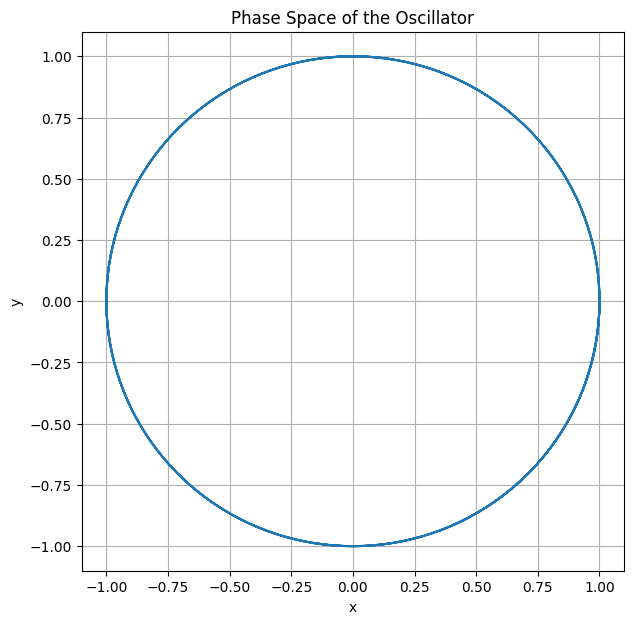

In [6]:
plt.figure(figsize=(7, 7))

plt.plot(x, y)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Phase Space of the Oscillator")
plt.grid(True)

plt.show()

# 6. The Lorenz System

Now we reach the system that you originally encountered.

The Lorenz system consists of three coupled ODEs:

    dx/dt = σ(y - x)

    dy/dt = x(ρ - z) - y

    dz/dt = xy - βz

The standard parameters are:

    σ = 10
    ρ = 28
    β = 8/3

The initial condition is commonly chosen as:

    x(0) = 1
    y(0) = 1
    z(0) = 1

The important thing to notice is that the variables are strongly coupled.

The evolution of x depends on y.

The evolution of y depends on x and z.

The evolution of z depends on x and y.

This interaction produces extremely complicated dynamics.

# 7. Implementing the Lorenz Equations

We translate the mathematical equations directly into Python.

Mathematics:

    dx/dt = σ(y - x)

becomes:

    dx_dt = sigma * (y - x)

Similarly:

    dy/dt = x(ρ - z) - y

becomes:

    dy_dt = x * (rho - z) - y

And:

    dz/dt = xy - βz

becomes:

    dz_dt = x * y - beta * z

In [7]:
def lorenz(t, state, sigma=10, rho=28, beta=8/3):
    """
    Lorenz dynamical system.

    Equations
    ---------
        dx/dt = sigma * (y - x)

        dy/dt = x * (rho - z) - y

        dz/dt = x * y - beta * z

    Parameters
    ----------
    t : float
        Current time.

    state : array-like
        Current state [x, y, z].

    sigma : float
        Prandtl number.

    rho : float
        Rayleigh number.

    beta : float
        Geometric parameter.

    Returns
    -------
    list
        [dx/dt, dy/dt, dz/dt]
    """

    x, y, z = state

    dx_dt = sigma * (y - x)
    dy_dt = x * (rho - z) - y
    dz_dt = x * y - beta * z

    return [dx_dt, dy_dt, dz_dt]

# 8. Simulating the Lorenz System

Let's simulate the system from:

    [x₀, y₀, z₀] = [1, 1, 1]

for 40 units of time.

We use `solve_ivp` to numerically approximate the trajectory.

In [8]:
initial_state = [1, 1, 1]

t_eval = np.linspace(0, 40, 10000)

lorenz_solution = solve_ivp(
    lorenz,
    (0, 40),
    initial_state,
    t_eval=t_eval,
    rtol=1e-9,
    atol=1e-11
)

print("Simulation successful:", lorenz_solution.success)
print("Number of points:", len(lorenz_solution.t))

Simulation successful: True
Number of points: 10000


# 9. Extracting x, y and z

The solution contains three variables.

Therefore:

    solution.y[0] → x(t)
    solution.y[1] → y(t)
    solution.y[2] → z(t)

In [ ]:
t = lorenz_solution.t

x = lorenz_solution.y[0]
y = lorenz_solution.y[1]
z = lorenz_solution.y[2]

print("First state:")
print(x[0], y[0], z[0])

print("\nFinal state:")
print(x[-1], y[-1], z[-1])

First state:
1.0 1.0 1.0

Final state:
-10.549977960601328 -2.14907027611197 37.33878121722704


# 10. Plotting the Variables

Let's first see how each variable changes with time.

Unlike the simple exponential equation from Notebook 01,
these variables do not follow a simple predictable curve.

They continuously interact with each other.

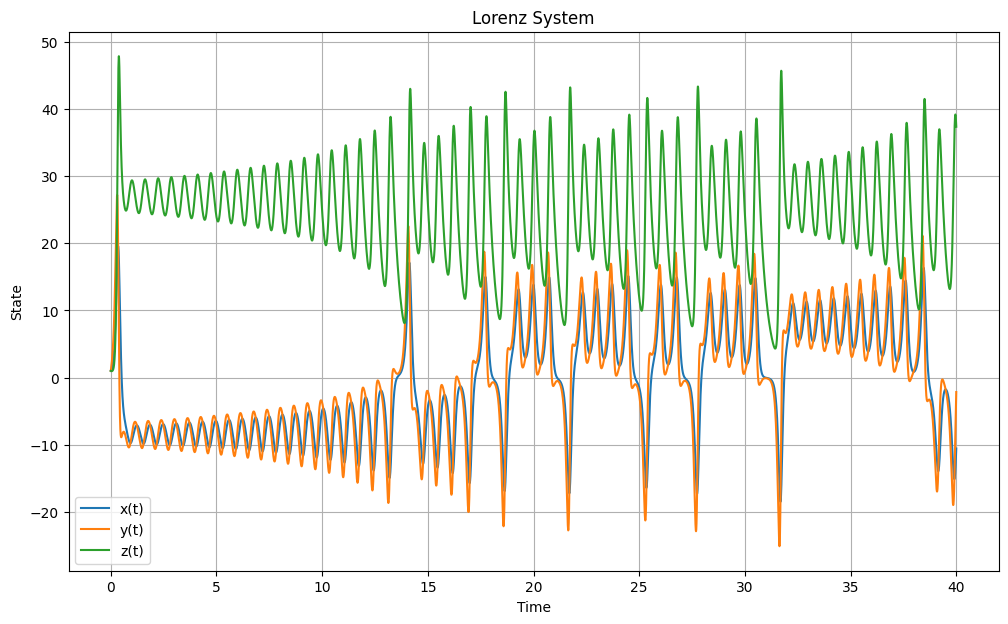

In [11]:
plt.figure(figsize=(12, 7))

plt.plot(t, x, label="x(t)")
plt.plot(t, y, label="y(t)")
plt.plot(t, z, label="z(t)")

plt.xlabel("Time")
plt.ylabel("State")
plt.title("Lorenz System")
plt.grid(True)
plt.legend()

plt.show()

# 11. The Lorenz Attractor

Now comes the interesting part.

Instead of plotting:

    x vs time

we can plot the trajectory in three-dimensional state space:

    x vs y vs z

The resulting structure is known as the Lorenz attractor.

The trajectory never simply settles into a fixed point.

Instead, it continuously evolves within a complicated region of state space.

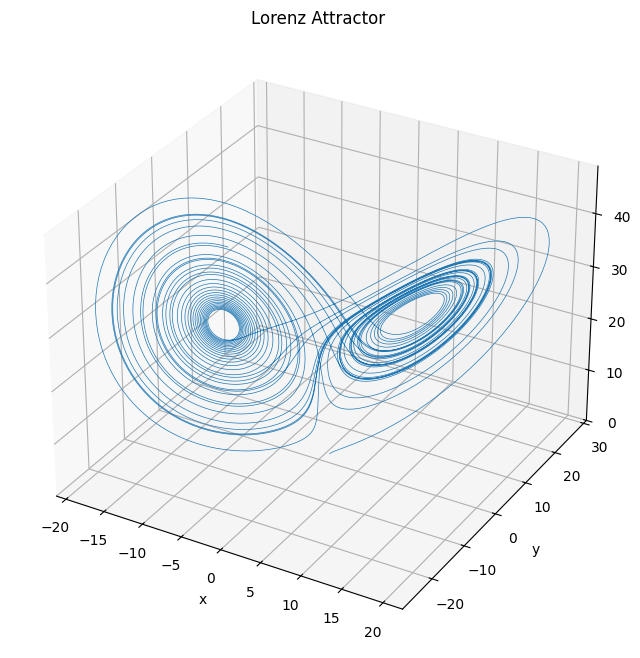

In [12]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection="3d")

ax.plot(x, y, z, linewidth=0.5)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

ax.set_title("Lorenz Attractor")

plt.show()

# 12. Why Is Lorenz Special?

The Lorenz system is famous because it exhibits chaotic behavior.

Chaos does NOT mean:

    "completely random"

The equations themselves are deterministic.

That means:

    Same initial condition
        ↓
    Same equations
        ↓
    Same trajectory

However, the system is extremely sensitive to its initial conditions.

A tiny change at the beginning can eventually produce a dramatically different
trajectory.

This is called:

    Sensitivity to Initial Conditions

It is commonly associated with the idea of the "butterfly effect."

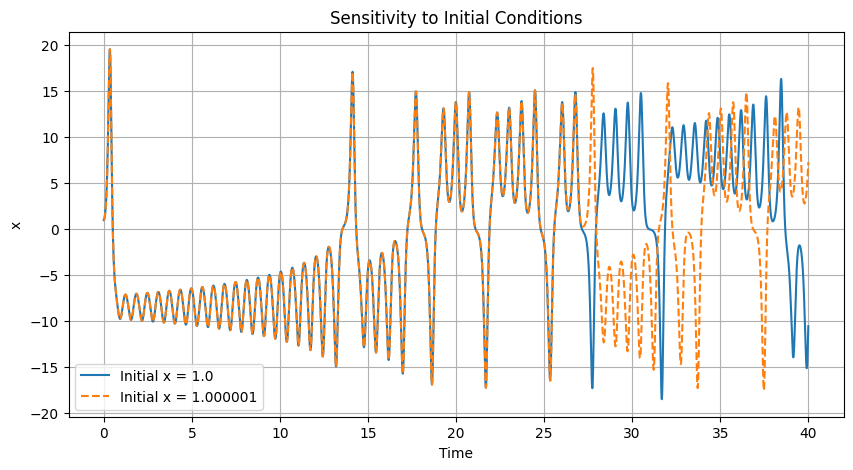

In [13]:
# First trajectory
solution_1 = solve_ivp(
    lorenz,
    (0, 40),
    [1.0, 1.0, 1.0],
    t_eval=t_eval,
    rtol=1e-9,
    atol=1e-11
)

# Second trajectory with a tiny perturbation
solution_2 = solve_ivp(
    lorenz,
    (0, 40),
    [1.000001, 1.0, 1.0],
    t_eval=t_eval,
    rtol=1e-9,
    atol=1e-11
)

x1 = solution_1.y[0]
x2 = solution_2.y[0]

plt.figure(figsize=(10, 5))

plt.plot(t_eval, x1, label="Initial x = 1.0")
plt.plot(t_eval, x2, "--", label="Initial x = 1.000001")

plt.xlabel("Time")
plt.ylabel("x")
plt.title("Sensitivity to Initial Conditions")
plt.grid(True)
plt.legend()

plt.show()

# 13. Measuring the Difference

The two simulations started almost identically:

    x₁(0) = 1.0

    x₂(0) = 1.000001

The initial difference is only:

    0.000001

Let's see how that difference evolves.